### Imports

In [14]:
from fundus_dataset import AugmentPair, FundusVesselDataset
from torch.utils.data import DataLoader

### Testing the Dataset

In [15]:
# -------------------------
# Paths
# -------------------------

img_dir = "fundus/train/Original/"
mask_dir = "fundus/train/Ground truth"

# -------------------------
# Dataset
# -------------------------

train_dataset = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=AugmentPair(crop_size=(512, 512)),
)

# -------------------------
# DataLoader
# -------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

# -------------------------
# Debug shape check
# -------------------------

images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)
print("Image min/max:", images.min().item(), images.max().item())
print("Mask unique values:", torch.unique(masks))


/home/user/bettiloss/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images shape: torch.Size([8, 3, 512, 512])
Masks shape: torch.Size([8, 1, 512, 512])
Images dtype: torch.float32
Masks dtype: torch.float32
Image min/max: 0.0 1.0
Mask unique values: tensor([0., 1.])


### Matplotlib to test out the DataLoader

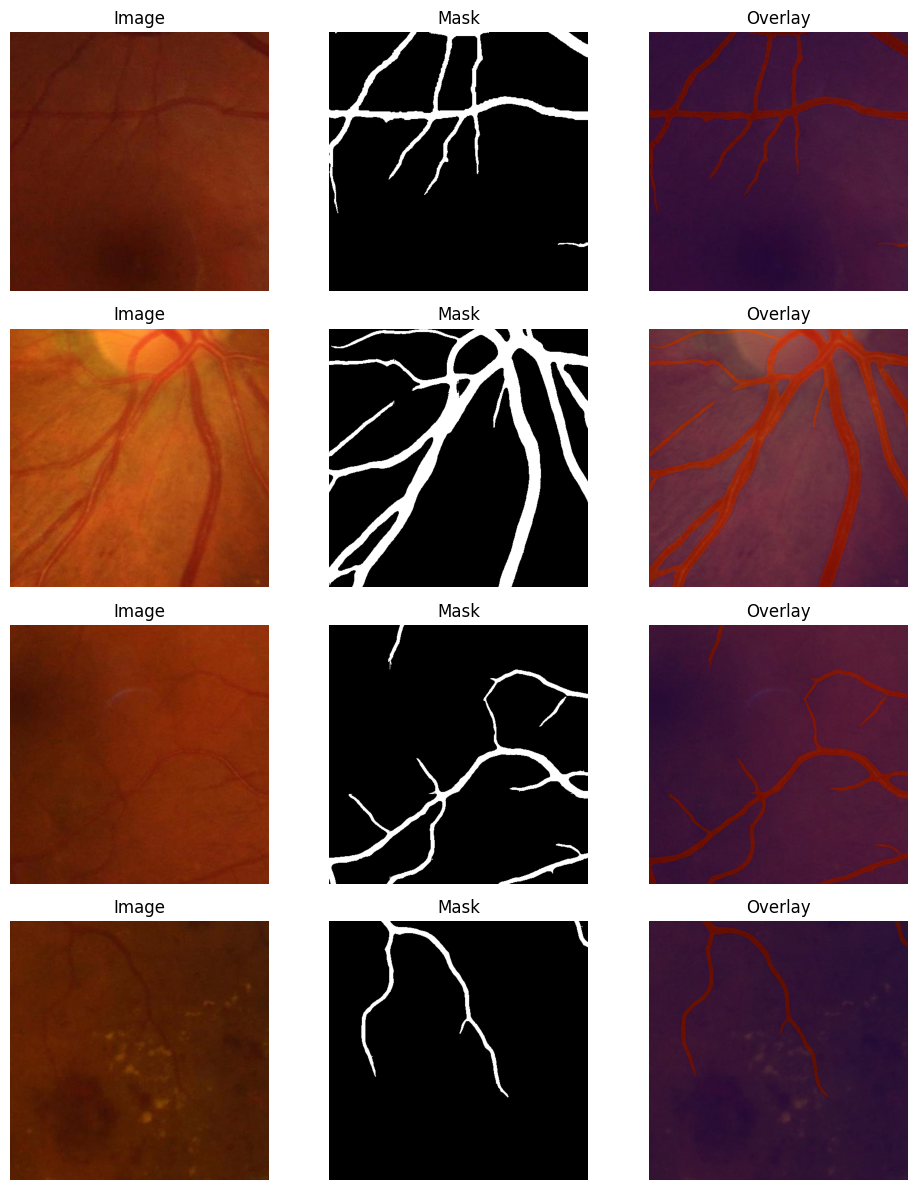

In [16]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(10, 12))

for i in range(4):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    mask = masks[i].squeeze(0).cpu().numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img)
    axes[i, 2].imshow(mask, cmap="jet", alpha=0.4)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()